In [3]:
import matplotlib.pyplot as plt
import numpy as np

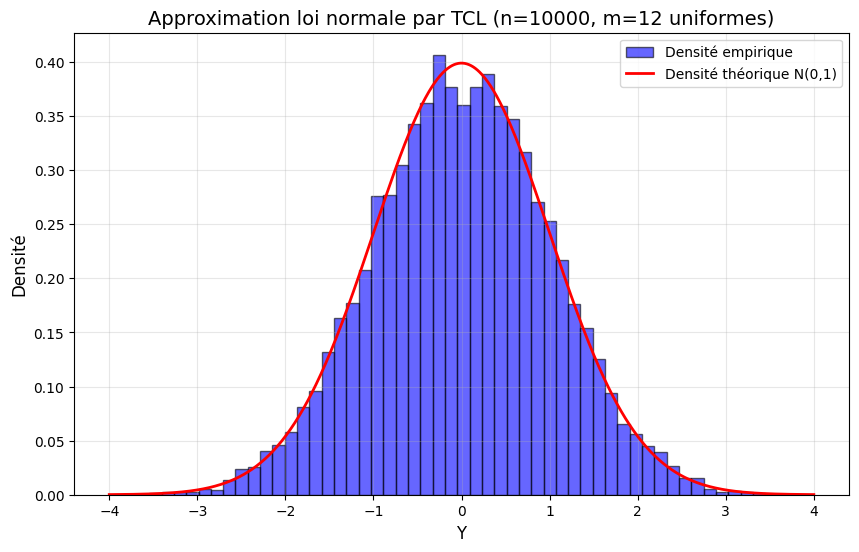

Moyenne empirique : 0.0075 (théorique : 0)
Écart-type empirique : 1.0058 (théorique : 1)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Paramètres
n = 10000  # Taille de l'échantillon final
m = 12     # Nombre de variables uniformes à sommer (m=12 simplifie les calculs)

# Générer n réalisations en utilisant le TCL
Y = []
for i in range(n):
    # Générer m variables uniformes U(0,1)
    U = np.random.uniform(0, 1, m)
    
    # Formule du TCL : (somme - espérance) / écart-type
    # Pour U(0,1) : E[U] = 0.5, Var[U] = 1/12
    # Somme de m variables : E[S] = m*0.5, Var[S] = m/12
    Y_i = (np.sum(U) - m*0.5) / np.sqrt(m/12)
    Y.append(Y_i)

Y = np.array(Y)

plt.figure(figsize=(10, 6))

plt.hist(Y, bins=50, density=True, alpha=0.6, color='blue', 
         edgecolor='black', label='Densité empirique')

x = np.linspace(-4, 4, 1000)
pdf_theorique = norm.pdf(x, 0, 1)
plt.plot(x, pdf_theorique, 'r-', linewidth=2, label='Densité théorique N(0,1)')

plt.xlabel('Y', fontsize=12)
plt.ylabel('Densité', fontsize=12)
plt.title(f'Approximation loi normale par TCL (n={n}, m={m} uniformes)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Statistiques
print(f"Moyenne empirique : {np.mean(Y):.4f} (théorique : 0)")
print(f"Écart-type empirique : {np.std(Y, ddof=1):.4f} (théorique : 1)")

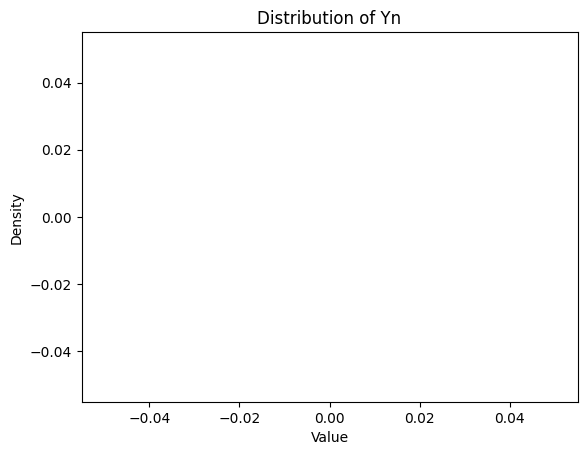

In [27]:
# question 1

size = 10000

def sim_exp(N, theta):
    Ech = np.zeros(N)
    for i in range(N):
        u = np.random.rand()
        Ech[i] = -np.log(1 - u) / theta

    return Ech

Yn = []

for _ in range(100):
    Un = sim_exp(size, 1)
    Yn.append((sum(Un) - (0.5 * size)) / np.sqrt(size) * np.sqrt(1 / 4))

a = -3
b = 3
delta = 0.06

plt.hist(Yn, bins=np.arange(a, b + delta, delta), density=True)
plt.title("Distribution of Yn")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()